In [ ]:
import cs_optimization_Optuna
import sys
import os
from datetime import datetime
import json
import pickle
import numpy as np
# プロジェクトのルートディレクトリをパスに追加
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
    
from src.simulation.run_emates import run_parallel_emates_simulations
from src.simulation.data_load import save_data_to_pickle
from src.util.path_manager import get_paths

current_time = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = current_time
os.makedirs(SAVE_DIR, exist_ok=True)
        
def total_costs_yearly(result_file) -> tuple:
    """充電ステーションのコスト計算:https://www.notion.so/2098044c3b9180acade1c42c52872eda?source=copy_link
    CSコスト：初期コスト＋運用コスト

    初期コストは以下の三つで構成される。
    1. 充電器本体コスト
    2. 変電設備コスト
    3. 一か所あたりの設置コスト

    運用コストは以下の三つで構成される。
    1. +保守コスト
    2. +電気料金（契約＋従量）
    3. -充電収益
    """
    # 
    # コストの定義-------------------------------------
    CHARGER_COST = {"50": 380, "90": 666, "100": 730} 
    SUBSTATION_COST_PER_KW = 2 # 万円/kw
    INSTALLATION_COST = 250 # 万円
    # 変数の設定-----------------------------------------
    # データ読み込み
    with open(result_file, 'rb') as f:
        emates_result = pickle.load(f)
    timeseries_kw = emates_result['time_series_kw']
    cs_config = emates_result['cs_config']
    
    capacity_list = cs_config['cap_kw']
    ports_list = cs_config['ports']
    actual_csids = timeseries_kw.columns.tolist()

    # 0ならNaNに
    capacity_list = [np.nan if cap == 0 else cap for cap in capacity_list]
    ports_list = [np.nan if port == 0 else port for port in ports_list]
    # ポート数と容量の配列を作成
    ports_array = np.array(ports_list)
    capacity_array = np.array(capacity_list)
    max_capacity = ports_array * capacity_array
    # -------------------------------------------
    
    # 1.充電器本体コスト
    charger_costs = np.array([CHARGER_COST[str(c)] for c in capacity_list])
    cs_costs = charger_costs * ports_array
    # 2.変電設備コスト
    substation_costs = (SUBSTATION_COST_PER_KW * max_capacity).reshape(-1)

    # 3.一か所あたりの設置コスト 
    installation_costs = np.array([INSTALLATION_COST] * len(actual_csids))
    total_installation_cost = installation_costs.sum()

    # 総コストの計算（充電器本体＋キュービクル＋工事コスト）
    initial_costs = cs_costs + substation_costs + installation_costs

    """運用コスト：
    保守＋電気料金（契約料金＋従量料金ー充電収益）
    CSごとのコストを計算する
    """
    # 1. コストの定義
    MAINTENANCE_COST_PER_YEAR = 30 # 万円/年.一か所あたり
    CONTRACT_COST_PER_KW_MONTH = 1911e-4 # 万円/kw
    USAGE_COST_PER_KWH_MONTH = 18e-4 # 万円/kWh
    CHARGING_PRICE_PER_KWH = 50e-4 # 万円/kWh
    # 2. 年間コスト計算
    maintainance_costs = np.array([MAINTENANCE_COST_PER_YEAR] * len(actual_csids))
    contract_costs = CONTRACT_COST_PER_KW_MONTH * max_capacity.reshape(-1) * 12 # 年間契約料金
    usage_costs = USAGE_COST_PER_KWH_MONTH * timeseries_kw.sum(axis=0) * 12 # 年間従量料金
    chaeging_revenue = CHARGING_PRICE_PER_KWH * timeseries_kw.sum(axis=0) * 12 # 年間充電収益
    # 3. 総コストの計算
    running_costs_yearly = maintainance_costs + contract_costs + usage_costs - chaeging_revenue

    # 初期コスト＋ 年間運用コスト（ベクター）
    total_costs = initial_costs + running_costs_yearly
    
    
    

    
    return total_costs.sum(), emates_result

def cs_placement_objective(trial):
    """CS配置最適化の目的関数"""
    paths = get_paths(1)  # worker_idは1と仮定
    # csList.txtの情報を取得
    cslist_file = paths['csList']
    with open(cslist_file, 'r') as f:
        cslist_data = f.readlines()
    cslist_data = [line.strip() for line in cslist_data if line.strip()]
    csids = [int(line.split(',')[0]) for line in cslist_data if line.strip()]
    ports_list = [int(line.split(',')[1]) for line in cslist_data if line.strip()]
    cap_kw_list = [int(line.split(',')[2]) for line in cslist_data if line.strip()]
    
    
    cs_config = {
        'csids': [],
        'ports': [],
        'cap_kw': []
    }
    for i, csid in enumerate(csids):
        # trialの最初は元々のデータを使用
        if trial.number == 0:
            ports = ports_list[i]
            capacity = cap_kw_list[i]
        else:        
            # 設置するかどうかを決定
            ports = trial.suggest_int(f'ports_{i}', 0, 4)
            if ports > 0:
                # 設置する場合のみ容量を決定
                capacity = trial.suggest_categorical(f'capacity_{i}', [50, 90, 100])
            else:
                # 設置しない場合は容量は任意（50に固定）
                capacity = 90
        # ✅ 修正：辞書に追加
        
        cs_config['csids'].append(csid)
        cs_config['ports'].append(ports)
        cs_config['cap_kw'].append(capacity)
        
    # 2. 制約チェック----------
    # 2.1. ポート数の合計が最大値を超えない
    total_ports = sum(cs_config['ports'])
    if total_ports > 17:  # 最大ポート数は17
        return float('inf')
    # 2.2. 設置箇所の数が最低2箇所
    # 2.2. 設置箇所の数が最低2箇所
    installed_locations = [i for i, port in enumerate(cs_config['ports']) if port > 0]
    if len(installed_locations) < 2:  # 最低2箇所は設置
        return float('inf')
    
    print(f"Trial {trial.number}: CS設定 = {cs_config}")

    #3. シミュレーション実行とコスト計算。evaluation_costを最小化したい！
    evaluation_cost, emates_results = simulate_and_calculate_cost(cs_config, trial)
    
    #4.ペナルティ
    # 最低限満たしてほしい条件：充電実現率80％以上の確保
    HOPED_CHARGING_RATE = 0.8
    vehicle_trip = emates_results['vehicle_trip']
    charging_loss = emates_results['charging_loss']
    
    num_charging_loss = len(charging_loss)
    num_charging_trip = len(vehicle_trip[vehicle_trip['startChargingTime'] != 0])
    satisfied_charging_rate = (num_charging_trip - num_charging_loss) / num_charging_trip
    if satisfied_charging_rate < HOPED_CHARGING_RATE:
        print(f"充電実現率が低い: {satisfied_charging_rate:.2%}。ペナルティを適用します。")
        # 実現率に応じたペナルティを追加
        evaluation_cost += (HOPED_CHARGING_RATE - satisfied_charging_rate) * 1000
    
    return evaluation_cost

def simulate_and_calculate_cost(cs_configs, trial) -> tuple:
    
    """シミュレーション実行とコスト計算（ダミー）"""
    # シミュレーションの実行

    run_parallel_emates_simulations(base_config=cs_configs, parallel_count=1)
    
    # データの保存
    results_filename = f"trial_{trial.number}.pkl"
    results_filepath = os.path.join(SAVE_DIR, results_filename)

    save_data_to_pickle(worker_id=1, filename=results_filepath)
    
    # 評価コストの計算
    evaluation_cost, emates_results = total_costs_yearly(result_file=results_filepath)
    
    return evaluation_cost, emates_results

# 最適化実行
study = cs_optimization_Optuna.create_study(direction='minimize')
study.optimize(cs_placement_objective, n_trials=20)

print(f"最適コスト: {study.best_value}")
print(f"最適配置: {study.best_params}")

# Optuna実行後のデータ保存

# 最適化結果の保存
optimization_results = {
    'best_value': study.best_value,
    'best_params': study.best_params,
    'n_trials': len(study.trials),
    'optimization_time': datetime.now().strftime('%Y%m%d_%H:%M:%S')
}

# 各試行の結果を保存
trials_data = []
for trial in study.trials:
    trial_info = {
        'number': trial.number,
        'value': trial.value,
        'params': trial.params,
        'state': trial.state.name
    }
    trials_data.append(trial_info)

optimization_results['trials'] = trials_data

# JSONファイルとして保存
results_dir = 'optimization_results'
os.makedirs(results_dir, exist_ok=True)

with open(os.path.join(results_dir, 'optuna_results.json'), 'w', encoding='utf-8') as f:
    json.dump(optimization_results, f, indent=2, ensure_ascii=False)

# Studyオブジェクト（学習済みモデル）を保存
study_filename = os.path.join(results_dir, 'optuna_study.pkl')
with open(study_filename, 'wb') as f:
    pickle.dump(study, f)

print(f"最適化結果を {results_dir}/optuna_results.json に保存しました")
print(f"学習済みStudyオブジェクトを {study_filename} に保存しました")

In [13]:
# 最適な結果を読み込む
import pickle
import pandas as pd
with open(r'20250622_1759\trial_19.pkl', 'rb') as f:
    result_iter20 = pickle.load(f)

In [7]:
# 取得した結果を表示
print("最適なシミュレーション結果:")
print(result_iter20.keys())
print("充電ステーションの設定:")
print(result_iter20['cs_config'])
print("年間コスト:")


最適なシミュレーション結果:
dict_keys(['time_series_kw', 'waiting_line', 'vehicle_trip', 'charging_loss', 'cs_config'])
充電ステーションの設定:
{'csids': [900000, 900002, 900004, 900006, 900008, 900010, 900012, 900014], 'ports': [3, 2, 0, 0, 1, 1, 0, 2], 'cap_kw': [50, 100, 90, 90, 90, 50, 90, 90]}
年間コスト:


=== 最良解（Trial 17）の詳細 ===
設置構成:
  CS_0: 3ポート × 90kW = 270kW
  CS_1: 2ポート × 100kW = 200kW
  CS_5: 1ポート × 50kW = 50kW
  CS_7: 2ポート × 50kW = 100kW

総計:
  総ポート数: 8
  総容量: 620kW
  年間利益: 492.15万円
  設置箇所数: 4箇所


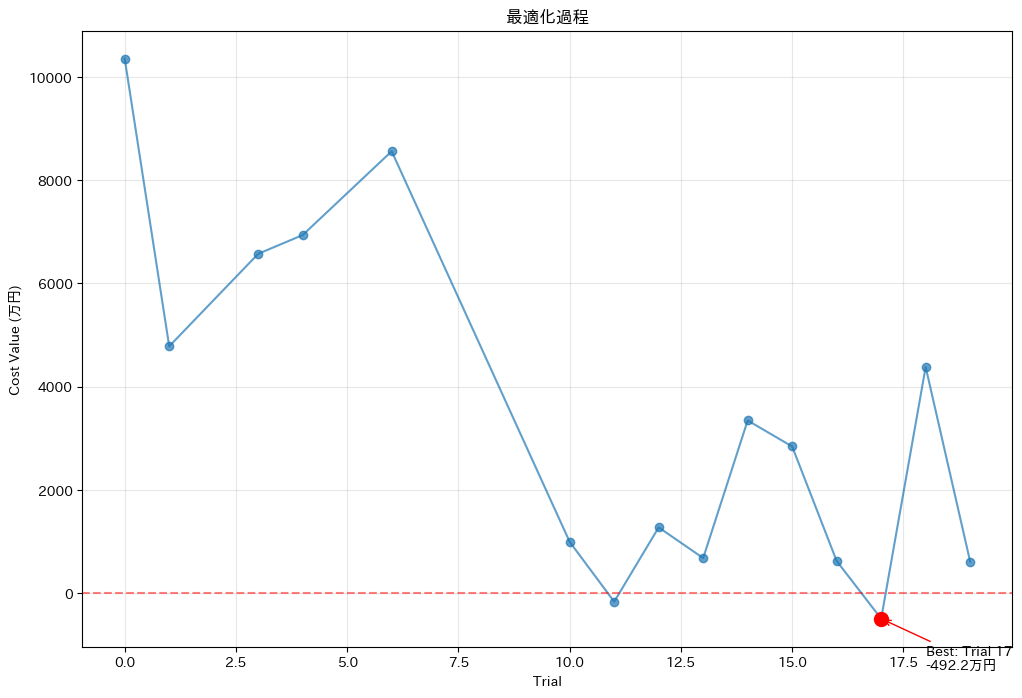

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib
import warnings
warnings.filterwarnings("ignore")

# 結果の可視化
def visualize_optimization_results():
    # データ準備
    trials = list(range(20))
    values = [
        10351.808, 4782.908, float('inf'), 6574.306, 6937.438,
        float('inf'), 8559.743, float('inf'), float('inf'), float('inf'),
        996.46, -162.86, 1276.46, 681.8, 3346.576,
        2843.16, 625.212, -492.152, 4382.552, 613.676
    ]
    
    # 無限大値を除外
    finite_values = [v for v in values if v != float('inf')]
    finite_trials = [i for i, v in enumerate(values) if v != float('inf')]
    
    # プロット
    plt.figure(figsize=(12, 8))
    
    # サブプロット1: 最適化過程
    plt.plot(finite_trials, finite_values, 'o-', alpha=0.7)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Trial')
    plt.ylabel('Cost Value (万円)')
    plt.title('最適化過程')
    plt.grid(True, alpha=0.3)
    
    # 最良解をハイライト
    best_trial = 17
    best_value = -492.152
    plt.scatter([best_trial], [best_value], color='red', s=100, zorder=5)
    plt.annotate(f'Best: Trial {best_trial}\n{best_value:.1f}万円', 
                xy=(best_trial, best_value), xytext=(best_trial+1, best_value-1000),
                arrowprops=dict(arrowstyle='->', color='red'))

# 実行
visualize_optimization_results()

# 最良解の詳細分析
print("=== 最良解（Trial 17）の詳細 ===")
best_params = {
    "ports_0": 3, "capacity_0": 90,
    "ports_1": 2, "capacity_1": 100,
    "ports_5": 1, "capacity_5": 50,
    "ports_7": 2, "capacity_7": 50
}

print("設置構成:")
total_ports = 0
total_capacity = 0
for i in range(8):
    ports_key = f"ports_{i}"
    capacity_key = f"capacity_{i}"
    
    if ports_key in best_params and best_params[ports_key] > 0:
        ports = best_params[ports_key]
        capacity = best_params[capacity_key]
        print(f"  CS_{i}: {ports}ポート × {capacity}kW = {ports*capacity}kW")
        total_ports += ports
        total_capacity += ports * capacity

print(f"\n総計:")
print(f"  総ポート数: {total_ports}")
print(f"  総容量: {total_capacity}kW")
print(f"  年間利益: 492.15万円")
print(f"  設置箇所数: 4箇所")

In [16]:
data = result_iter20
# 2つ目のセル：データ確認
timeseries_kw = data['time_series_kw']
timeseries_waiting_line = data['waiting_line']
vehicle_trip = data['vehicle_trip']
cs_config = data['cs_config']
charging_loss = data['charging_loss']
actual_csids = timeseries_kw.columns.tolist()
candidate_csids = cs_config['csids']

print("=== データ概要 ===")
print(f"時系列データ: {timeseries_kw.shape}")
print(f"期間: {timeseries_kw.index.min()} - {timeseries_kw.index.max()}")
print(f"CS数: {len(cs_config['csids'])}")
print(f"EV車両トリップ数: {len(vehicle_trip)}")
print(f"充電損失: {charging_loss.shape}")
print(f"設置CS: {actual_csids}")
print(f"候補地数: {len(candidate_csids)}")

cs_config_df = pd.DataFrame(cs_config)


# 4つ目のセル：充電ステーションの設定確認
# CSの出力とポート数
capacity_list = cs_config['cap_kw']
ports_list = cs_config['ports']
# 0ならNaNに
capacity_list = [np.nan if cap == 0 else cap for cap in capacity_list]
ports_list = [np.nan if port == 0 else port for port in ports_list]
#
ports_array = np.array(ports_list)
capacity_array = np.array(capacity_list)

# 評価指標：利用率，待ち行列
# 各CSの利用率を計算　利用率＝ 実際の充電量 / 最大充電容量
max_capacity = ports_array * capacity_array
utilization = timeseries_kw / max_capacity

# 後のために形状を調整
max_capacity.shape = (-1,1)  

utilization_mean = utilization.mean(axis=0)
print(f"各CSの平均利用率:\n{utilization_mean}")
print(f"最大容量：{max_capacity}")

# 各CSの待ち行列
waiting_line_mean = timeseries_waiting_line.mean(axis=0)

# 評価指標：待ち時間,走行距離
# 待ち時間＝ 充電開始時間 - 待機列に入った時間
charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] != 0]
# EndTimeがNaNの行を特定
nan_endtime = charging_trip['EndTime'].isna()
print(f"EndTimeがNaNの件数: {nan_endtime.sum()}")

# 完了した充電のみを抽出
completed_charging = charging_trip[~nan_endtime].copy()
print(f"完了した充電件数: {len(completed_charging)}")

# 以降の分析は完了した充電データのみ使用
charging_trip = completed_charging

waiting_times = charging_trip['startChargingTime'].values - charging_trip['WaitingEntryTime'].values

# どこで充電待ちが発生しているかを確認するために，0秒以上の待ち時間があるものを抽出
is_waiting = waiting_times > 0
non_zero_wait = charging_trip[is_waiting]

non_zero_waiting_times = waiting_times[is_waiting]

waiting_cs = non_zero_wait['CSID'].value_counts()


print(f"充電待ち時間の平均: {np.mean(waiting_times):.2f} 秒")
print(f"充電待ち時間の最大: {np.max(waiting_times):.2f} 秒")
print(f"充電待ちが発生しているCS:{waiting_cs.index.tolist()}")


=== データ概要 ===
時系列データ: (1440, 8)
期間: 60 - 86400
CS数: 8
EV車両トリップ数: 19771
充電損失: (13, 6)
設置CS: ['900000', '900002', '900004', '900006', '900008', '900010', '900012', '900014']
候補地数: 8
各CSの平均利用率:
900000    0.451852
900002    0.306250
900004         NaN
900006         NaN
900008    0.000000
900010    0.209722
900012         NaN
900014    0.093056
dtype: float64
最大容量：[[150.]
 [200.]
 [ nan]
 [ nan]
 [ 90.]
 [ 50.]
 [ nan]
 [180.]]
EndTimeがNaNの件数: 4
完了した充電件数: 102
充電待ち時間の平均: 35.35 秒
充電待ち時間の最大: 1136.40 秒
充電待ちが発生しているCS:[900000.0, 900002.0]


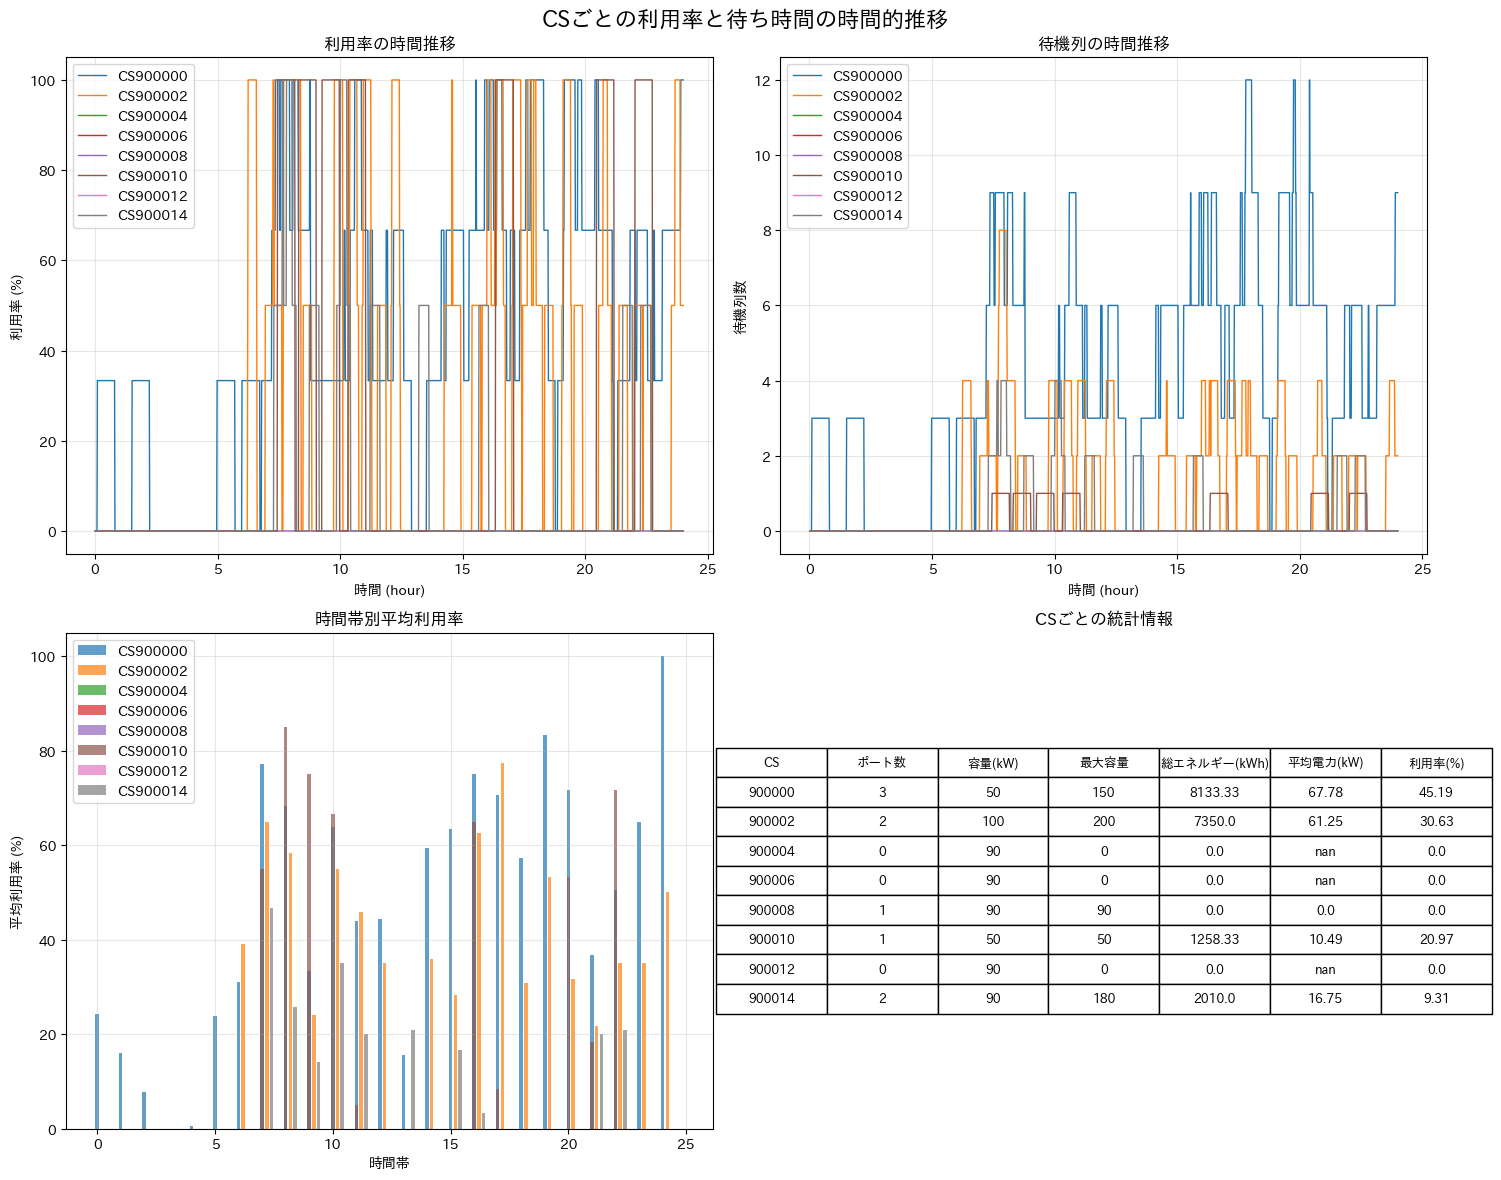

=== 待ち時間の詳細分析 ===
待ち時間が発生した充電回数: 6
全充電回数: 102
待ち時間発生率: 5.9%
平均待ち時間: 601.0秒 (10.0分)
最大待ち時間: 1136.4秒 (18.9分)


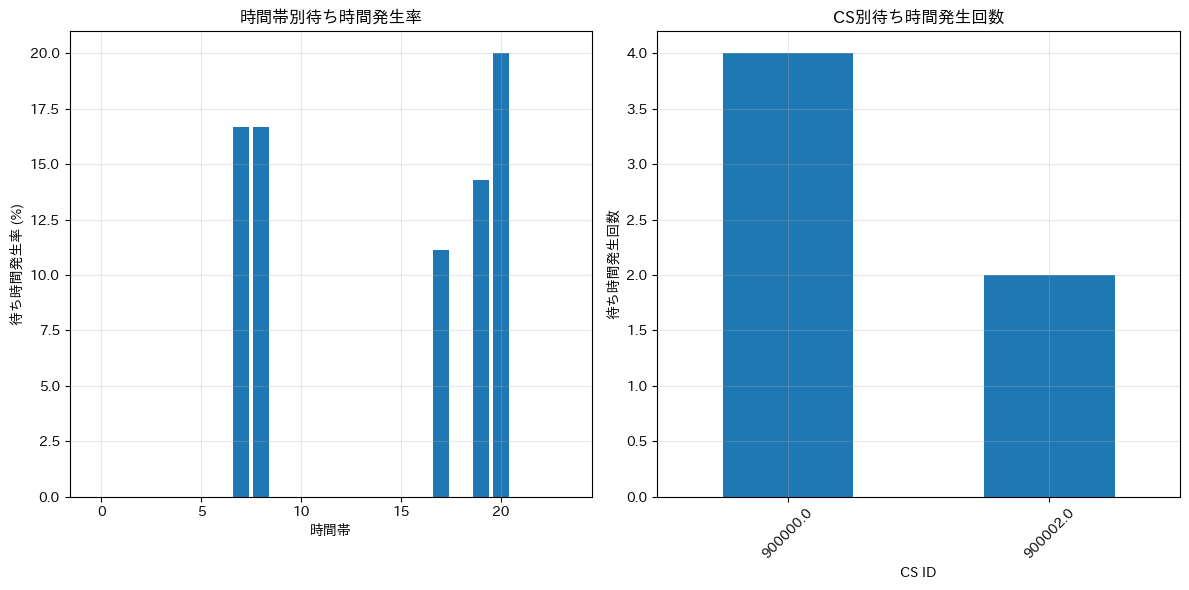


=== CSごとの詳細統計 ===
    CS  ポート数  容量(kW)  最大容量  総エネルギー(kWh)  平均電力(kW)    利用率(%)
900000     3      50   150  8133.333333 67.777778 45.185185
900002     2     100   200  7350.000000 61.250000 30.625000
900004     0      90     0     0.000000       NaN  0.000000
900006     0      90     0     0.000000       NaN  0.000000
900008     1      90    90     0.000000  0.000000  0.000000
900010     1      50    50  1258.333333 10.486111 20.972222
900012     0      90     0     0.000000       NaN  0.000000
900014     2      90   180  2010.000000 16.750000  9.305556


In [20]:
import seaborn as sns
from datetime import datetime, timedelta

# CSごとの利用率と待ち時間の時間的推移分析
import matplotlib.pyplot as plt

# データの前処理
# 時間軸を時間単位に変換（ElapsedTimeは秒）
timeseries_kw['hour'] = timeseries_kw.index / 3600
timeseries_waiting_line['hour'] = timeseries_waiting_line.index / 3600

# 設置されているCSのみを抽出
installed_cs = [col for col in timeseries_kw.columns if col in [str(csid) for csid in actual_csids]]

# 1. CSごとの利用率の時間的推移
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('CSごとの利用率と待ち時間の時間的推移', fontsize=16)

# 利用率の計算（最大容量に対する割合）
cs_utilization = {}
for cs in installed_cs:
    cs_idx = cs_config['csids'].index(int(cs))
    max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
    cs_utilization[cs] = timeseries_kw[cs] / max_capacity * 100

# 1-1. 利用率の時間推移
ax1 = axes[0, 0]
for cs in installed_cs:
    ax1.plot(timeseries_kw['hour'], cs_utilization[cs], label=f'CS{cs}', linewidth=1)
ax1.set_xlabel('時間 (hour)')
ax1.set_ylabel('利用率 (%)')
ax1.set_title('利用率の時間推移')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1-2. 待機列の時間推移
ax2 = axes[0, 1]
for cs in installed_cs:
    ax2.plot(timeseries_waiting_line['hour'], timeseries_waiting_line[cs], 
             label=f'CS{cs}', linewidth=1)
ax2.set_xlabel('時間 (hour)')
ax2.set_ylabel('待機列数')
ax2.set_title('待機列の時間推移')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 2. 時間帯別の利用状況分析
# 時間帯別の平均利用率とピーク利用率
hourly_stats = {}
for cs in installed_cs:
    cs_data = timeseries_kw[cs].groupby(timeseries_kw.index // 3600).agg(['mean', 'max'])
    hourly_stats[cs] = cs_data

# 2-1. 時間帯別平均利用率
ax3 = axes[1, 0]
hours = range(24)
for cs in installed_cs:
    cs_idx = cs_config['csids'].index(int(cs))
    max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
    avg_utilization = hourly_stats[cs]['mean'] / max_capacity * 100
    ax3.bar(np.arange(len(avg_utilization)) + 0.1 * int(cs[-1]), avg_utilization, 
            width=0.15, label=f'CS{cs}', alpha=0.7)
ax3.set_xlabel('時間帯')
ax3.set_ylabel('平均利用率 (%)')
ax3.set_title('時間帯別平均利用率')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 2-2. CSごとの統計情報
ax4 = axes[1, 1]
cs_stats = []
for cs in installed_cs:
    cs_idx = cs_config['csids'].index(int(cs))
    ports = cs_config['ports'][cs_idx]
    capacity = cs_config['cap_kw'][cs_idx]
    max_capacity = ports * capacity
    
    total_energy = timeseries_kw[cs].sum()
    avg_power = timeseries_kw[cs].mean()
    peak_power = timeseries_kw[cs].max()
    if max_capacity == 0:
        utilization_rate = 0
    else:
        utilization_rate = (avg_power / max_capacity) * 100 
    
    cs_stats.append({
        'CS': cs,
        'ポート数': ports,
        '容量(kW)': capacity,
        '最大容量': max_capacity,
        '総エネルギー(kWh)': total_energy/12,  # 5分間隔なので12で割る
        '平均電力(kW)': avg_power,
        '利用率(%)': utilization_rate
    })

# 統計テーブルの表示
cs_stats_df = pd.DataFrame(cs_stats)
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=cs_stats_df.round(2).values,
                  colLabels=cs_stats_df.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax4.set_title('CSごとの統計情報')

plt.tight_layout()
plt.show()

# 3. 待ち時間の詳細分析
print("=== 待ち時間の詳細分析 ===")
print(f"待ち時間が発生した充電回数: {len(non_zero_wait)}")
print(f"全充電回数: {len(charging_trip)}")
print(f"待ち時間発生率: {len(non_zero_wait)/len(charging_trip)*100:.1f}%")
print(f"平均待ち時間: {np.mean(non_zero_waiting_times):.1f}秒 ({np.mean(non_zero_waiting_times)/60:.1f}分)")
print(f"最大待ち時間: {np.max(non_zero_waiting_times):.1f}秒 ({np.max(non_zero_waiting_times)/60:.1f}分)")

# 4. 時間帯別の待ち時間分析
charging_trip['hour'] = (charging_trip['WaitingEntryTime'] // 3600).astype(int)
hourly_waiting = charging_trip.groupby('hour').agg({
    'EVID': 'count',
    'startChargingTime': lambda x: ((x - charging_trip.loc[x.index, 'WaitingEntryTime']) > 0).sum()
}).rename(columns={'EVID': 'total_charging', 'startChargingTime': 'waiting_count'})

hourly_waiting['waiting_rate'] = hourly_waiting['waiting_count'] / hourly_waiting['total_charging'] * 100

# 時間帯別待ち時間発生率のプロット
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(hourly_waiting.index, hourly_waiting['waiting_rate'])
plt.xlabel('時間帯')
plt.ylabel('待ち時間発生率 (%)')
plt.title('時間帯別待ち時間発生率')
plt.grid(True, alpha=0.3)

# CSごとの待ち時間発生箇所
plt.subplot(1, 2, 2)
waiting_cs.plot(kind='bar')
plt.xlabel('CS ID')
plt.ylabel('待ち時間発生回数')
plt.title('CS別待ち時間発生回数')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== CSごとの詳細統計 ===")
print(cs_stats_df.to_string(index=False))


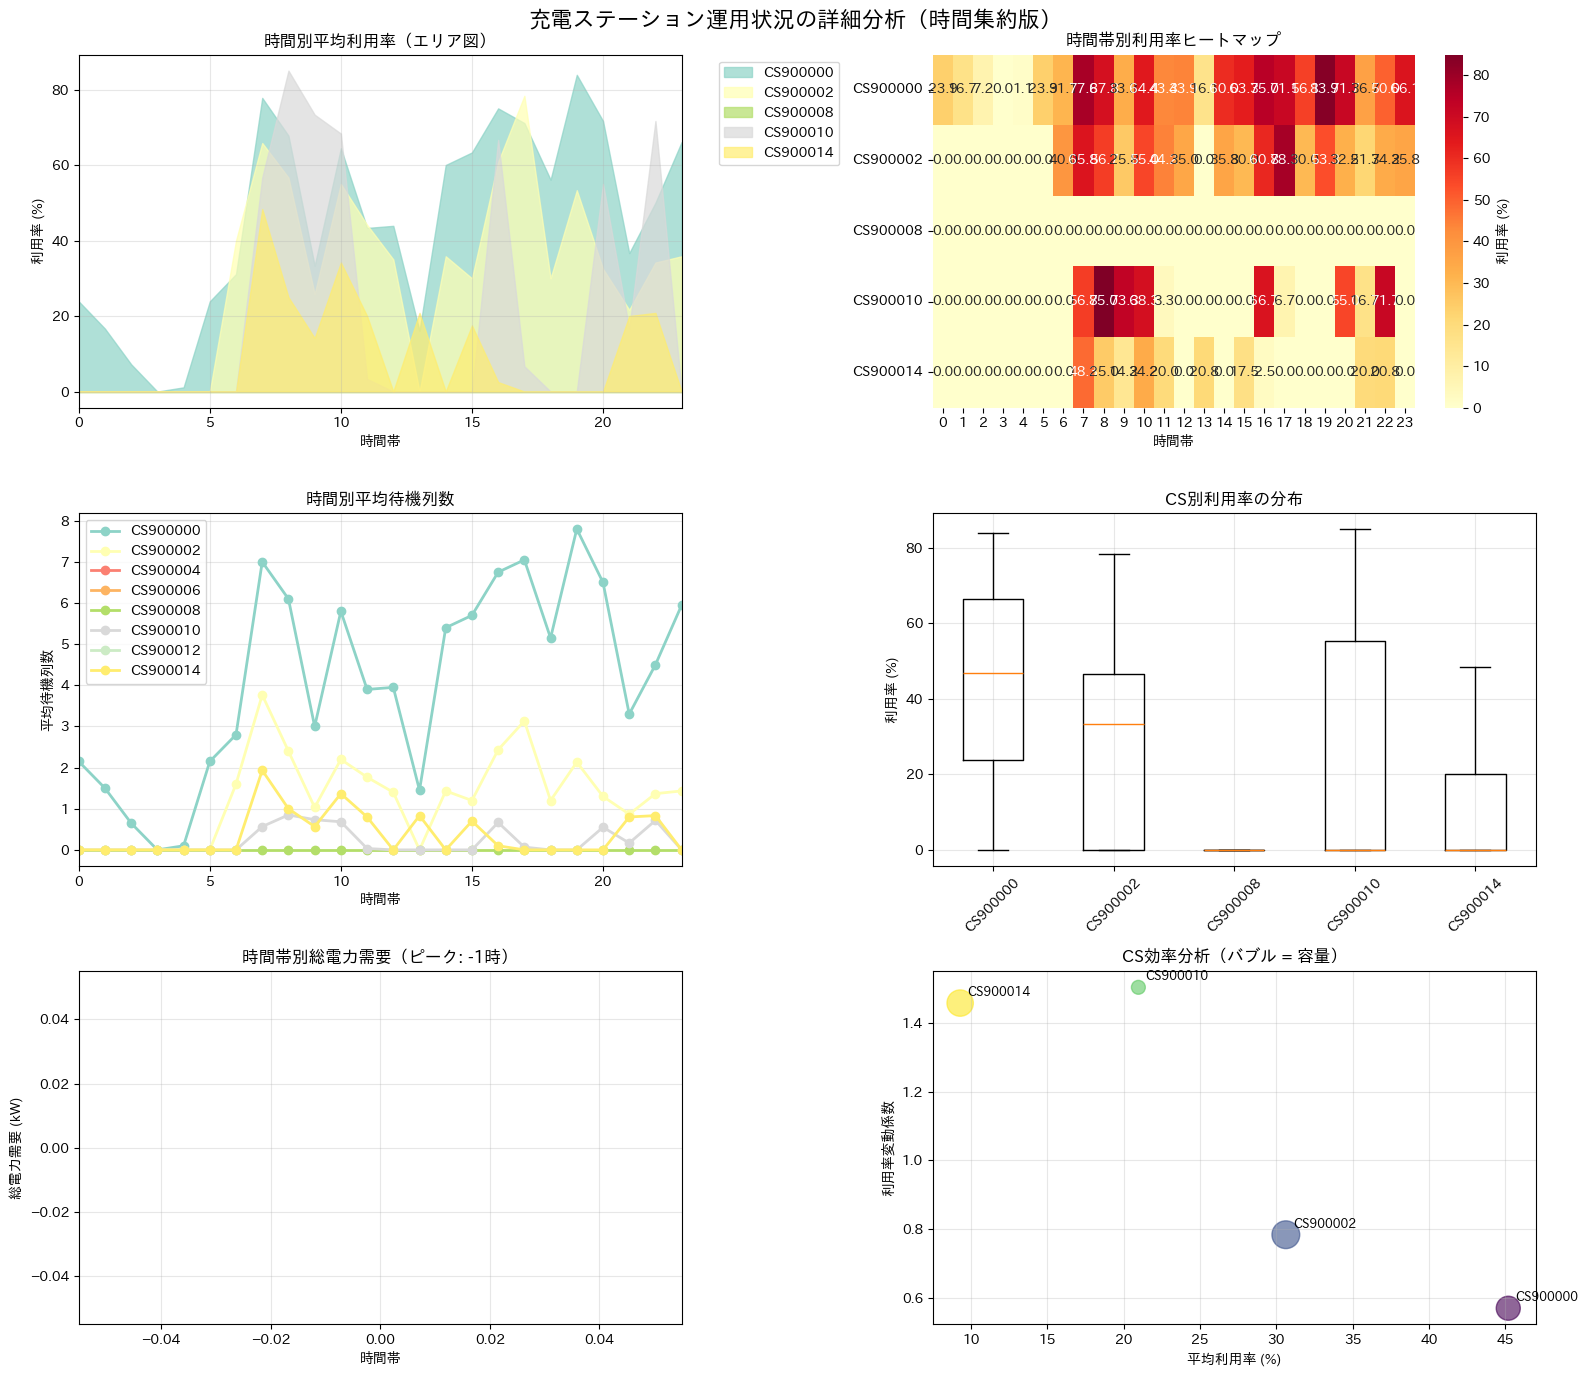

In [23]:
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

# ✅ 改善1: データを時間単位で集約
def create_aggregated_timeseries(timeseries_kw, timeseries_waiting_line, aggregation_method='1H'):
    """
    時系列データを指定した間隔で集約
    aggregation_method: '1H'(1時間), '30min'(30分), '15min'(15分)
    """
    # インデックスを時間に変換
    timeseries_kw.index = pd.to_timedelta(timeseries_kw.index, unit='s')
    timeseries_waiting_line.index = pd.to_timedelta(timeseries_waiting_line.index, unit='s')
    
    # 時間単位で集約
    kw_hourly = timeseries_kw.resample(aggregation_method).agg({
        col: ['mean', 'max', 'std'] for col in timeseries_kw.columns
    })
    
    waiting_hourly = timeseries_waiting_line.resample(aggregation_method).agg({
        col: ['mean', 'max'] for col in timeseries_waiting_line.columns
    })
    
    return kw_hourly, waiting_hourly

# データ集約の実行
kw_hourly, waiting_hourly = create_aggregated_timeseries(timeseries_kw, timeseries_waiting_line)

# ✅ 改善2: 見やすい時間軸の可視化
def plot_improved_timeseries():
    """改善された時系列プロット"""
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('充電ステーション運用状況の詳細分析（時間集約版）', fontsize=16)
    
    # 設置されているCSのみを抽出
    installed_cs = [col for col in timeseries_kw.columns if col != 'hour']
    
    # カラーパレットの設定
    colors = plt.cm.Set3(np.linspace(0, 1, len(installed_cs)))
    
    # 1-1. 時間別平均利用率（エリア図）
    ax1 = axes[0, 0]
    utilization_data = []
    
    for i, cs in enumerate(installed_cs):
        cs_idx = cs_config['csids'].index(int(cs))
        max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
        
        if max_capacity > 0:
            hourly_util = kw_hourly[cs]['mean'] / max_capacity * 100
            utilization_data.append(hourly_util.values)
            
            # 時間軸を0-23に変換
            hours = np.arange(len(hourly_util))
            ax1.fill_between(hours, hourly_util, alpha=0.7, 
                           label=f'CS{cs}', color=colors[i])
    
    ax1.set_xlabel('時間帯')
    ax1.set_ylabel('利用率 (%)')
    ax1.set_title('時間別平均利用率（エリア図）')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 23)
    
    # 1-2. ピーク時利用率比較（ヒートマップ）
    ax2 = axes[0, 1]
    heatmap_data = []
    cs_labels = []
    
    for cs in installed_cs:
        cs_idx = cs_config['csids'].index(int(cs))
        max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
        
        if max_capacity > 0:
            hourly_util = kw_hourly[cs]['mean'] / max_capacity * 100
            heatmap_data.append(hourly_util.values)
            cs_labels.append(f'CS{cs}')
    
    if heatmap_data:
        sns.heatmap(heatmap_data, 
                   xticklabels=range(24), 
                   yticklabels=cs_labels,
                   cmap='YlOrRd', 
                   annot=True, 
                   fmt='.1f',
                   ax=ax2,
                   cbar_kws={'label': '利用率 (%)'})
    ax2.set_title('時間帯別利用率ヒートマップ')
    ax2.set_xlabel('時間帯')
    
    # 2-1. 待機列の変化パターン
    ax3 = axes[1, 0]
    for i, cs in enumerate(installed_cs):
        if cs in waiting_hourly.columns:
            hourly_waiting = waiting_hourly[cs]['mean']
            hours = np.arange(len(hourly_waiting))
            ax3.plot(hours, hourly_waiting, 
                    marker='o', linewidth=2, 
                    label=f'CS{cs}', color=colors[i])
    
    ax3.set_xlabel('時間帯')
    ax3.set_ylabel('平均待機列数')
    ax3.set_title('時間別平均待機列数')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 23)
    
    # 2-2. 利用率変動の統計（箱ひげ図）
    ax4 = axes[1, 1]
    utilization_box_data = []
    box_labels = []
    
    for cs in installed_cs:
        cs_idx = cs_config['csids'].index(int(cs))
        max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
        
        if max_capacity > 0:
            hourly_util = kw_hourly[cs]['mean'] / max_capacity * 100
            utilization_box_data.append(hourly_util.dropna().values)
            box_labels.append(f'CS{cs}')
    
    if utilization_box_data:
        ax4.boxplot(utilization_box_data, labels=box_labels)
    ax4.set_ylabel('利用率 (%)')
    ax4.set_title('CS別利用率の分布')
    ax4.grid(True, alpha=0.3)
    plt.setp(ax4.get_xticklabels(), rotation=45)
    
        # 3-1. ピーク時間帯の特定
    ax5 = axes[2, 0]

    # ✅ 修正: levelパラメータを使わずに合計を計算
    # 各時間帯での全CS合計負荷を計算
    total_load_data = []
    for hour in range(24):
        hour_sum = 0
        for cs in installed_cs:
            if cs in kw_hourly.columns:
                try:
                    hour_sum += kw_hourly[cs]['mean'].iloc[hour]
                except IndexError:
                    continue  # データが存在しない時間帯はスキップ
        total_load_data.append(hour_sum)

    total_load = pd.Series(total_load_data, index=range(24))
    hours = np.arange(len(total_load))

    bars = ax5.bar(hours, total_load, alpha=0.7, color='skyblue')

    # ピーク時間をハイライト
    peak_hour_idx = total_load.argmax()
    if len(bars) > peak_hour_idx:
        bars[peak_hour_idx].set_color('red')

    ax5.set_xlabel('時間帯')
    ax5.set_ylabel('総電力需要 (kW)')
    ax5.set_title(f'時間帯別総電力需要（ピーク: {peak_hour_idx}時）')
    ax5.grid(True, alpha=0.3)

    # ピーク時間を注釈
    if len(total_load) > 0:
        peak_value = total_load.max()
        ax5.annotate(f'ピーク\n{peak_value:.1f}kW', 
                    xy=(peak_hour_idx, peak_value),
                    xytext=(peak_hour_idx+2, peak_value*0.8),
                    arrowprops=dict(arrowstyle='->', color='red'))
    
    # 3-2. 効率指標の時間変化
    ax6 = axes[2, 1]
    
    # CS別の時間変動係数を計算
    efficiency_metrics = []
    
    for cs in installed_cs:
        cs_idx = cs_config['csids'].index(int(cs))
        max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
        
        if max_capacity > 0:
            hourly_util = kw_hourly[cs]['mean'] / max_capacity * 100
            cv = hourly_util.std() / hourly_util.mean()  # 変動係数
            avg_util = hourly_util.mean()
            
            efficiency_metrics.append({
                'CS': f'CS{cs}',
                'Average_Utilization': avg_util,
                'Variability': cv,
                'Max_Capacity': max_capacity
            })
    
    if efficiency_metrics:
        eff_df = pd.DataFrame(efficiency_metrics)
        
        # バブルチャート（x: 平均利用率, y: 変動係数, size: 容量）
        scatter = ax6.scatter(eff_df['Average_Utilization'], 
                            eff_df['Variability'],
                            s=eff_df['Max_Capacity']*2,  # 容量に比例したサイズ
                            alpha=0.6, 
                            c=range(len(eff_df)), 
                            cmap='viridis')
        
        # ラベル追加
        for i, row in eff_df.iterrows():
            ax6.annotate(row['CS'], 
                        (row['Average_Utilization'], row['Variability']),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax6.set_xlabel('平均利用率 (%)')
    ax6.set_ylabel('利用率変動係数')
    ax6.set_title('CS効率分析（バブル = 容量）')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 実行
plot_improved_timeseries()